In [430]:
import sys
import importlib
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import re
import pandas as pd
import numpy as np
import pandas as pd
from functools import reduce
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact, combine_pvalues
from scipy.stats import chi2_contingency
import pysam
from tqdm import tqdm
import random
from scipy.optimize import curve_fit
from collections import defaultdict


plt.rcdefaults()
# mpl.rcParams[''] = 42
# mpl.rcParams['font.size'] = 14

plt.style.use('default')

def theme_classic():
    mpl.rcParams.update({
        'pdf.fonttype': 42,
        'font.size': 12,
        'axes.grid': False,
        'axes.facecolor': 'white',
        'figure.facecolor': 'white',
        'axes.edgecolor': 'black',
        'axes.linewidth': 1.0,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'xtick.direction': 'out',
        'ytick.direction': 'out'
    })

theme_classic()

## nascent rna read length distribution

In [ ]:
# adapter trimming performed with pychopper:
# ../src/sh/250722_adapter_trimming_nascent2.sh

In [58]:
def get_readlen(fq):
    linecount = 0
    readlen = []
    for line in open(fq):
        if linecount % 4 == 1:
            readlen.append(len(line.rstrip()))
        linecount += 1
    return readlen

In [28]:
inpath = '../data/rna/nascentRNA/trimmed/'
fqs = sorted([f for f in os.listdir(inpath) if f.endswith('_trimmed.fastq') & f.startswith('250722')])
samples = ['MUT rep1', 'MUT rep2', 'WT rep1', 'WT rep2']
samples_ordered = ['WT rep1', 'WT rep2', 'MUT rep1', "MUT rep2"]
readlens = []
for s in samples_ordered:
    i = samples.index(s)
    print(s)
    fq = inpath + fqs[i]
    readlen = get_readlen(fq)
    readlens.append(readlen)

WT rep1
WT rep2
MUT rep1
MUT rep2


In [36]:
outf = open('../data/supp/Supp_nascent_rna_trimmed_readlength_qc.tsv', 'w')
outf.write('sample\treadlength_mean\treadlength_median\treadlength_std\n')

for i, readlen in enumerate(readlens):
    sample = samples_ordered[i]
    print(sample)
    outf.write(
        f"{sample}\t"
        f"{np.mean(readlen):.4f}\t{np.median(readlen):.4f}\t{np.std(readlen):.4f}\n"
    )

outf.close()

WT rep1
WT rep2
MUT rep1
MUT rep2


WT rep1
WT rep2
WT rep3
MUT rep1


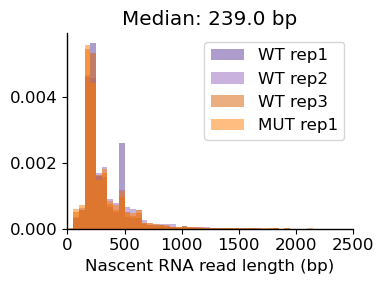

In [70]:
cmap = ['#5D3A9B', '#9467bd', '#d95f02', '#ff7f00']
plt.figure(figsize=(4, 3))
for i, readlen in enumerate(readlens):
    print(samples_ordered[i])
    readlen_sampled = random.sample(readlen, 10000)
    plt.hist(readlen_sampled, bins=np.arange(0, 2500, 50), density=True, alpha = 0.5, color= cmap[i], label = samples_ordered[i])

plt.xlabel('Nascent RNA read length (bp)')
median_wt1 = np.median(readlens[0])
plt.title(f'Median: {median_wt1} bp')
plt.xlim(0, 2500)
plt.legend()
plt.tight_layout()
plt.savefig('../figures/Supp_nascent_rna_readlength_after_trimming.pdf')

## mature rna read length distribution

In [60]:
# adapter trimming performed with pychopper:
# ../src/sh/241118_adapter_trimming_teloprime.sh

In [61]:
inpath = '../data/rna/matureRNA/trimmed/'
fqs = sorted([f for f in os.listdir(inpath) if f.endswith('_trimmed.fastq') & f.startswith('241120')])
fqs

['241120_barcode01_trimmed.fastq',
 '241120_barcode02_trimmed.fastq',
 '241120_barcode03_trimmed.fastq',
 '241120_barcode04_trimmed.fastq',
 '241120_barcode05_trimmed.fastq',
 '241120_barcode06_trimmed.fastq']

In [62]:
samples_ordered = ['WT rep1', 'WT rep2', 'WT rep3', 'MUT rep1', 'MUT rep2', 'MUT rep3']
readlens_telo = []
for i, s in enumerate(samples_ordered):
    print(s)
    fq = inpath + fqs[i]
    readlen = get_readlen(fq)
    readlens_telo.append(readlen)

WT rep1
WT rep2
WT rep3
MUT rep1
MUT rep2
MUT rep3


In [63]:
outf = open('../data/supp/Supp_mature_rna_trimmed_readlength_qc.tsv', 'w')
outf.write('sample\treadlength_mean\treadlength_median\treadlength_std\n')

for i, readlen in enumerate(readlens_telo):
    sample = samples_ordered[i]
    print(sample)
    outf.write(
        f"{sample}\t"
        f"{np.mean(readlen):.4f}\t{np.median(readlen):.4f}\t{np.std(readlen):.4f}\n"
    )

outf.close()

WT rep1
WT rep2
WT rep3
MUT rep1
MUT rep2
MUT rep3


WT rep1
WT rep2
WT rep3
MUT rep1
MUT rep2
MUT rep3


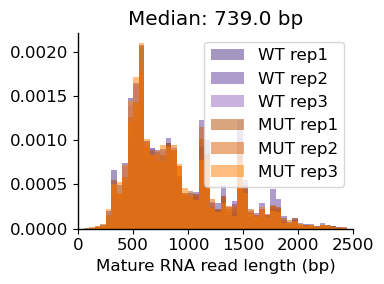

In [69]:
cmap = ['#4B2E83', '#5D3A9B', '#9467bd', '#b24d00', '#d95f02', '#ff7f00']
plt.figure(figsize=(4, 3))
for i, readlen in enumerate(readlens_telo):
    print(samples_ordered[i])
    readlen_sampled = random.sample(readlen, 10000)
    plt.hist(readlen_sampled, bins=np.arange(0, 2500, 50), density=True, alpha = 0.5, color= cmap[i], label = samples_ordered[i])

plt.xlabel('Mature RNA read length (bp)')
median_wt1 = np.median(readlens_telo[0])
plt.title(f'Median: {median_wt1} bp')
plt.xlim(0, 2500)
plt.legend()
plt.tight_layout()
plt.savefig('../figures/Supp_mature_rna_readlength_after_trimming.pdf')

## nascent rna filtering quality control

In [449]:
## all reads
inpath = "/private/groups/brookslab/gabai/projects/yeastMeth/data/rna/nascentRNA/riboPool/alignment/"
fs = os.listdir(inpath)
flagstat_files = sorted([f for f in fs if re.search(r'_trimmed.sorted.flagstat$', f)])
samples = ['MUT rep1', 'MUT rep2', 'WT rep1', 'WT rep2']
samples_i  = [2, 3, 0, 1]
flagstat_files = [flagstat_files[i] for i in samples_i]
samples = [samples[i] for i in samples_i]
print(flagstat_files)
print(samples)

totals, mappeds = [], []
for i, f in enumerate(flagstat_files):
    
    with open(os.path.join(inpath, f)) as fh:
        content = fh.read()

    total = re.search(r"(\d+) \+ \d+ primary", content)
    mapped = re.search(r"(\d+) \+ \d+ primary mapped", content)
    
    n_total = int(total.group(1)) if total else 0
    n_mapped = int(mapped.group(1)) if mapped else 0
    totals.append(n_total)
    mappeds.append(n_mapped)

['250908_RiboPool_LSK114_ys18_rep1_nRNA_trimmed.sorted.flagstat', '250908_RiboPool_LSK114_ys18_rep2_nRNA_trimmed.sorted.flagstat', '250908_RiboPool_LSK114_ym209_rep1_nRNA_trimmed.sorted.flagstat', '250908_RiboPool_LSK114_ym209_rep2_nRNA_trimmed.sorted.flagstat']
['WT rep1', 'WT rep2', 'MUT rep1', 'MUT rep2']


In [450]:
## first round no capp
inpath = "/private/groups/brookslab/gabai/projects/yeastMeth/data/rna/nascentRNA/riboPool/alignment/no_cap/"
fs = os.listdir(inpath)
flagstat_files = sorted([f for f in fs if re.search(r'flagstat$', f)])
samples = ['MUT rep1', 'MUT rep2', 'WT rep1', 'WT rep2']
samples_i  = [2, 3, 0, 1]
flagstat_files = [flagstat_files[i] for i in samples_i]
samples = [samples[i] for i in samples_i]
print(flagstat_files)
print(samples)

totals_nocap, mappeds_nocap = [], []
for i, f in enumerate(flagstat_files):
    
    with open(os.path.join(inpath, f)) as fh:
        content = fh.read()

    total = re.search(r"(\d+) \+ \d+ primary", content)
    mapped = re.search(r"(\d+) \+ \d+ primary mapped", content)
    
    n_total = int(total.group(1)) if total else 0
    n_mapped = int(mapped.group(1)) if mapped else 0
    totals_nocap.append(n_total)
    mappeds_nocap.append(n_mapped)

['250915_RiboPool_LSK114_ys18_rep1_nRNA_trimmed.pass.sorted.nocap.flagstat', '250915_RiboPool_LSK114_ys18_rep2_nRNA_trimmed.pass.sorted.nocap.flagstat', '250915_RiboPool_LSK114_ym209_rep1_nRNA_trimmed.pass.sorted.nocap.flagstat', '250915_RiboPool_LSK114_ym209_rep2_nRNA_trimmed.pass.sorted.nocap.flagstat']
['WT rep1', 'WT rep2', 'MUT rep1', 'MUT rep2']


In [451]:
## first round left
inpath = "/private/groups/brookslab/gabai/projects/yeastMeth/data/rna/nascentRNA/riboPool/alignment/inter_bam/"
fs = os.listdir(inpath)
flagstat_files = sorted([f for f in fs if re.search(r'flagstat$', f)])
samples = ['MUT rep1', 'MUT rep2', 'WT rep1', 'WT rep2']
samples_i  = [2, 3, 0, 1]
flagstat_files = [flagstat_files[i] for i in samples_i]
samples = [samples[i] for i in samples_i]
print(flagstat_files)
print(samples)

totals_capped_v1, mappeds_capped_v1 = [], []
for i, f in enumerate(flagstat_files):
    
    with open(os.path.join(inpath, f)) as fh:
        content = fh.read()

    total = re.search(r"(\d+) \+ \d+ primary", content)
    mapped = re.search(r"(\d+) \+ \d+ primary mapped", content)
    
    n_total = int(total.group(1)) if total else 0
    n_mapped = int(mapped.group(1)) if mapped else 0
    totals_capped_v1.append(n_total)
    mappeds_capped_v1.append(n_mapped)

['250915_RiboPool_LSK114_ys18_rep1_nRNA_trimmed.pass.sorted.flagstat', '250915_RiboPool_LSK114_ys18_rep2_nRNA_trimmed.pass.sorted.flagstat', '250915_RiboPool_LSK114_ym209_rep1_nRNA_trimmed.pass.sorted.flagstat', '250915_RiboPool_LSK114_ym209_rep2_nRNA_trimmed.pass.sorted.flagstat']
['WT rep1', 'WT rep2', 'MUT rep1', 'MUT rep2']


In [452]:
## final left
inpath = "/private/groups/brookslab/gabai/projects/yeastMeth/data/rna/nascentRNA/riboPool/alignment/"
fs = os.listdir(inpath)
flagstat_files = sorted([f for f in fs if re.search(r'_final.pass.sorted.flagstat$', f)])
samples = ['MUT rep1', 'MUT rep2', 'WT rep1', 'WT rep2']
samples_i  = [2, 3, 0, 1]
flagstat_files = [flagstat_files[i] for i in samples_i]
samples = [samples[i] for i in samples_i]
print(flagstat_files)
print(samples)

totals_final, mappeds_final = [], []
for i, f in enumerate(flagstat_files):
    
    with open(os.path.join(inpath, f)) as fh:
        content = fh.read()

    total = re.search(r"(\d+) \+ \d+ primary", content)
    mapped = re.search(r"(\d+) \+ \d+ primary mapped", content)
    
    n_total = int(total.group(1)) if total else 0
    n_mapped = int(mapped.group(1)) if mapped else 0
    totals_final.append(n_total)
    mappeds_final.append(n_mapped)

['250915_RiboPool_LSK114_ys18_rep1_nRNA_trimmed_final.pass.sorted.flagstat', '250915_RiboPool_LSK114_ys18_rep2_nRNA_trimmed_final.pass.sorted.flagstat', '250915_RiboPool_LSK114_ym209_rep1_nRNA_trimmed_final.pass.sorted.flagstat', '250915_RiboPool_LSK114_ym209_rep2_nRNA_trimmed_final.pass.sorted.flagstat']
['WT rep1', 'WT rep2', 'MUT rep1', 'MUT rep2']


### total primary genomic aligned reads vs aligned reads

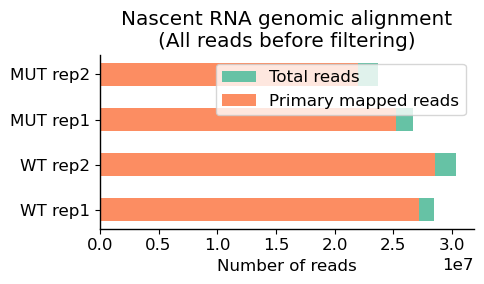

In [453]:
outf = open('../data/supp/Supp_nascent_rna_total_read_vs_aligned_reads_qc.tsv', 'w')
outf.write('sample\tprimary_total\tprimary_mapped\n')
for i,s in enumerate(samples):
    outf.write(f'{s}\t{totals_final[i]}\t{mappeds_final[i]}\n')
outf.close()

plt.figure(figsize=(5, 3))
plt.barh(samples, totals, height=0.5, color='#66c2a5', label='Total reads')
plt.barh(samples, mappeds, height=0.5, color='#fc8d62', label='Primary mapped reads')
plt.title('Nascent RNA genomic alignment\n(All reads before filtering)')
plt.xlabel("Number of reads")
plt.legend()
plt.tight_layout()
plt.savefig('../figures/Supp_nascent_rna_total_number_of_reads.pdf')
plt.show()
plt.close()

## step by step filtering break down

In [454]:
nocap =  np.array(mappeds_nocap) - (np.array(mappeds_final) - np.array(mappeds_capped_v1))
polya = (np.array(mappeds)-np.array(mappeds_capped_v1) - np.array(mappeds_nocap))

In [155]:
outf = open('../data/supp/Supp_nascent_rna_aligned_reads_filtering.tsv', 'w')
outf.write('sample\ttotal\tno_cap\tpolya\tfinal\n')
for i,s in enumerate(samples):
    outf.write(f'{s}\t{mappeds[i]}\t{nocap[i]}\t{polya[i]}\t{mappeds_final[i]}\n')
    assert nocap[i] + polya[i] + mappeds_final[i] == mappeds[i]
outf.close()

In [455]:
# fraction of reads remained
np.array(mappeds_final)/np.array(mappeds)

array([0.05395267, 0.08622759, 0.06785573, 0.0751173 ])

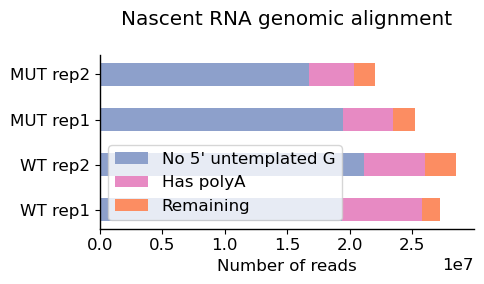

In [456]:
plt.figure(figsize=(5, 3))
# plt.barh(samples, mappeds, height=0.5, color='#66c2a5', label='Primary mapped reads')
plt.barh(samples, nocap, height=0.5, color='#8da0cb', label="No 5' untemplated G")
plt.barh(samples, polya, height=0.5, left=nocap, color='#e78ac3', label="Has polyA")
plt.barh(samples, mappeds_final, height=0.5, left=[n + p for n, p in zip(nocap, polya)], color='#fc8d62', label="Remaining")

plt.title('Nascent RNA genomic alignment\n')
plt.xlabel("Number of reads")
plt.legend()
plt.tight_layout()
plt.savefig('../figures/Supp_nascent_rna_numer_of_reads_filtered.pdf')
plt.show()
plt.close()

### jaccard index on nascet 5' cap filtering

In [307]:
inpath = "../data/supp/"
fs = os.listdir(inpath)
jaccard_files = sorted([f for f in fs if re.search(r'^260227_jaccard_index', f)])
jaccard_files

['260227_jaccard_index_final_nascent_rna_ys18_rep1.tsv',
 '260227_jaccard_index_final_nascent_rna_ys18_rep2.tsv',
 '260227_jaccard_index_no_cap_nascent_rna_ys18_rep1.tsv',
 '260227_jaccard_index_no_cap_nascent_rna_ys18_rep2.tsv',
 '260227_jaccard_index_total_reads_nascent_rna_ys18_rep1.tsv',
 '260227_jaccard_index_total_reads_nascent_rna_ys18_rep2.tsv']

In [308]:
labels = ["raw total reads", "No 5' untemplated G", "5' untemplated G", ]
samples = ['WT rep1', 'WT rep2']
samples_i = [4,5,2,3,0,1]
jaccard_files = [jaccard_files[i] for i in samples_i]
print(labels)
jaccard_files

['raw total reads', "No 5' untemplated G", "5' untemplated G"]


['260227_jaccard_index_total_reads_nascent_rna_ys18_rep1.tsv',
 '260227_jaccard_index_total_reads_nascent_rna_ys18_rep2.tsv',
 '260227_jaccard_index_no_cap_nascent_rna_ys18_rep1.tsv',
 '260227_jaccard_index_no_cap_nascent_rna_ys18_rep2.tsv',
 '260227_jaccard_index_final_nascent_rna_ys18_rep1.tsv',
 '260227_jaccard_index_final_nascent_rna_ys18_rep2.tsv']

In [313]:
def read_jaccard_tb(jr):
    with open(jr, 'r') as infile:
        header = infile.readlines(1)
        for line in infile:
            line = line.strip().split('\t')
            jaccard = float(line[0])
            overlap = int(line[3])
            non_overlap = float(line[2])- overlap

    return jaccard, overlap, non_overlap

jaccards = []
overlaps = []
non_overlaps = []

for jaccard_file in jaccard_files:
    j, o, no = read_jaccard_tb(inpath + jaccard_file)
    jaccards.append(j)
    overlaps.append(o)
    non_overlaps.append(no)

# chi square test:
all_ps = []
for group in [[(0,4), (2,4)], [(1,5), (3,5)]]:
    pvals = []
    
    for (x,y) in group:
        table = np.array([
            [overlaps[x], non_overlaps[x]],
            [overlaps[y], non_overlaps[y]]
        ])
        chi2, p, dof, expected = chi2_contingency(table)
        pvals.append(p)
    all_ps.append(pvals)

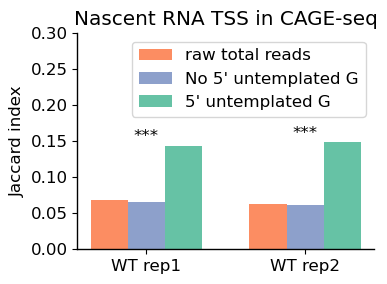

In [310]:
cmap = ['#fc8d62', '#8da0cb','#66c2a5']
plt.figure(figsize=(4,3))
x = np.arange(0, 3, 1.5)
width = 0.35

total = [jaccards[0], jaccards[1]]
nocap = [jaccards[2], jaccards[3]]
cap = [jaccards[4], jaccards[5]]

plt.bar(x-width/2, total, width = 0.35, color=cmap[0], label=labels[0])
plt.bar(x+width/2, nocap, width = 0.35, color=cmap[1], label=labels[1])
plt.bar(x+width*3/2, cap, width = 0.35, color=cmap[2], label=labels[2])

plt.xticks(x+width/2, samples)

def stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'

for i in range(len(x)):
    ymax = max(total[i], nocap[i], cap[i])
    for ps in all_ps:
        plt.text(
            x[i],
            ymax + 0.002,
            stars(ave_ps[i]),
            ha='center',
            va='bottom',
            fontsize=12
        )


plt.ylabel("Jaccard index")
plt.title('Nascent RNA TSS in CAGE-seq')
plt.ylim(0, 0.3)
plt.legend()
plt.tight_layout()
plt.savefig('../figures/Supp_nascent_rna_jaccard.pdf')
plt.show()
plt.close()

### precision recall on cage-seq

In [184]:
inpath = "../data/supp/"
fs = os.listdir(inpath)
pr_files = sorted([f for f in fs if re.search(r'^260227_precision_recall', f)])
samples = ["WT rep1 (5' untemplated G)", "WT rep2 (5' untemplated G)", "WT rep1 (No 5' untemplated G)", "WT rep2 (No 5' untemplated G)"]
samples_i = [0, 2, 1, 3]
pr_files = [pr_files[i] for i in samples_i]
samples = [samples[i] for i in samples_i]
print(pr_files)
print(samples)

['260227_precision_recall_final_nascent_rna_ys18_rep1.tsv', '260227_precision_recall_no_cap_nascent_rna_ys18_rep1.tsv', '260227_precision_recall_final_nascent_rna_ys18_rep2.tsv', '260227_precision_recall_no_cap_nascent_rna_ys18_rep2.tsv']
["WT rep1 (5' capped)", "WT rep1 (No 5' cap)", "WT rep2 (5' capped)", "WT rep2 (No 5' cap)"]


In [220]:
precisions = []
recalls = []
f1s = []
def read_precision_recall(pr):
    with open(pr, 'r') as infile:
        header = infile.readlines(1)
        for line in infile:
            line = line.strip().split('\t')
            pre = float(line[4])
            recall = float(line[5])
                        
            if pre + recall == 0:
                f1 = 0
            else:
                f1 = 2 * (pre * recall) / (pre + recall)
    return pre, recall, f1

for pr_file in pr_files:
    p, r, f1 = read_precision_recall(inpath + pr_file)
    precisions.append(p)
    recalls.append(r)
    f1s.append(f1)

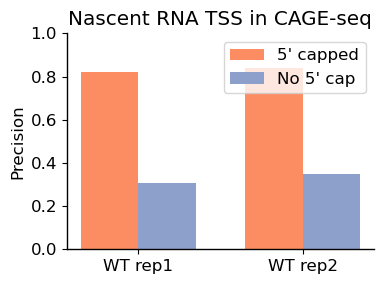

In [216]:
cmap = ['#fc8d62', '#8da0cb']
labels = ["5' untemplated G", "No 5' untemplated G"]

x = np.arange(2)  # WT rep1, WT rep2
width = 0.35
cap = [precisions[0], precisions[2]]
nocap = [precisions[1], precisions[3]]

plt.figure(figsize=(4,3))

plt.bar(x - width/2, cap, width, color=cmap[0], label=labels[0])
plt.bar(x + width/2, nocap, width, color=cmap[1], label=labels[1])

plt.xticks(x, ['WT rep1', 'WT rep2'])
plt.ylabel("Precision")
plt.title('Nascent RNA TSS in CAGE-seq')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.savefig('../figures/Supp_nascent_rna_precision.pdf')
plt.show()
plt.close()


cmap = ['#fc8d62', '#8da0cb']
labels = ["5' untemplated G", "No 5' untemplated G"]

cap = [recalls[0], recalls[2]]
nocap = [recalls[1], recalls[3]]

plt.figure(figsize=(4,3))

plt.bar(x - width/2, cap, width, color=cmap[0], label=labels[0])
plt.bar(x + width/2, nocap, width, color=cmap[1], label=labels[1])

plt.xticks(x, ['WT rep1', 'WT rep2'])
plt.ylabel("Recall")
plt.title('Nascent RNA TSS in CAGE-seq')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.savefig('../figures/Supp_nascent_rna_recall.pdf')
plt.show()
plt.close()


cmap = ['#fc8d62', '#8da0cb']
labels = ["5' untemplated G", "No 5' untemplated G"]

cap = [f1s[0], f1s[2]]
nocap = [f1s[1], f1s[3]]

plt.figure(figsize=(4,3))

plt.bar(x - width/2, cap, width, color=cmap[0], label=labels[0])
plt.bar(x + width/2, nocap, width, color=cmap[1], label=labels[1])

plt.xticks(x, ['WT rep1', 'WT rep2'])
plt.ylabel("F1 score")
plt.title('Nascent RNA TSS in CAGE-seq')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.savefig('../figures/Supp_nascent_rna_F1_score.pdf')
plt.show()
plt.close()

## nascent rna aligned readlength after filtering

In [346]:
inpath = "../data/rna/nascentRNA/alignment/"
fs = os.listdir(inpath)
bams = sorted([f for f in fs if re.search(r'.pass.sorted.bam$', f)])
samples = ['MUT rep1', 'MUT rep2', 'WT rep1', 'WT rep2']
samples_i  = [2, 3, 0, 1]
bams = [bams[i] for i in samples_i]
samples = [samples[i] for i in samples_i]
print(bams)
print(samples)

['250915_RiboPool_LSK114_ys18_rep1_nRNA_trimmed_final.pass.sorted.bam', '250915_RiboPool_LSK114_ys18_rep2_nRNA_trimmed_final.pass.sorted.bam', '250915_RiboPool_LSK114_ym209_rep1_nRNA_trimmed_final.pass.sorted.bam', '250915_RiboPool_LSK114_ym209_rep2_nRNA_trimmed_final.pass.sorted.bam']
['WT rep1', 'WT rep2', 'MUT rep1', 'MUT rep2']


In [342]:
def read_level_qc(bam, max_reads=None):
    readLen, aveReadqual = [], []
    readCount = 0
    
    samfile = pysam.AlignmentFile(bam, "rb")
    for s in samfile:
        if s.is_mapped and not s.is_supplementary and not s.is_secondary:
            readLen.append(s.query_length + 1)
            aveReadqual.append(np.mean(s.query_qualities))
            readCount += 1
        
        if max_reads and readCount >= max_reads:
            break

    samfile.close()
    return readLen, aveReadqual, readCount

In [347]:
outf = open('../data/supp/Supp_nascent_rna_final_aligned_readlength_qc.tsv', 'w')
outf.write('sample\treadlength_mean\treadlength_median\treadlength_std\t''read_quality_mean\tread_quality_median\tread_quality_std\n')

allreadLens, allreadQuals, readCounts = [], [], []
for i, bam in enumerate(bams):
    print(samples[i])
    readLens, readQuals, readCount = read_level_qc(inpath + bam)
    
    outf.write(
        f"{samples[i]}\t"
        f"{np.mean(readLens):.4f}\t{np.median(readLens):.4f}\t{np.std(readLens):.4f}\t"
        f"{np.mean(readQuals):.4f}\t{np.median(readQuals):.4f}\t{np.std(readQuals):.4f}\n"
    )

    allreadLens.append(readLens)
    allreadQuals.append(readQuals)
    readCounts.append(readCount)

outf.close()

WT rep1
WT rep2
MUT rep1
MUT rep2


WT rep1
WT rep2
MUT rep1
MUT rep2


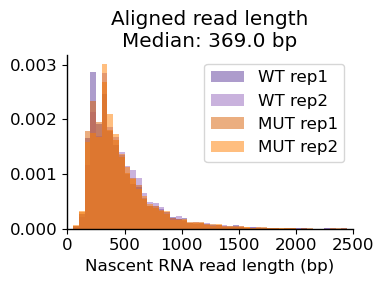

In [348]:
cmap = ['#5D3A9B', '#9467bd', '#d95f02', '#ff7f00']
plt.figure(figsize=(4, 3))
for i, readlen in enumerate(allreadLens):
    print(samples[i])
    readlen_sampled = random.sample(readlen, 10000)
    plt.hist(readlen_sampled, bins=np.arange(0, 2500, 50), density=True, alpha = 0.5, color= cmap[i], label = samples[i])

plt.xlabel('Nascent RNA read length (bp)')
median_wt1 = np.median(allreadLens[0])
plt.title(f'Aligned read length\nMedian: {median_wt1} bp')
plt.xlim(0, 2500)
plt.legend()
plt.tight_layout()
plt.savefig('../figures/Supp_nascent_rna_final_aligned_readlength.pdf')

In [439]:
inpath = "../data/rna/nascentRNA/alignment/"
fs = os.listdir(inpath)
bams = sorted([f for f in fs if re.search(r'.pass.sorted.bam$', f)])
samples = ['MUT rep1', 'MUT rep2', 'WT rep1', 'WT rep2']
samples_i  = [2, 3, 0, 1]
bams = [bams[i] for i in samples_i]
samples = [samples[i] for i in samples_i]
print(bams)
print(samples)

counts = {label: defaultdict(int) for label in samples}

for bam_path, label in zip(bams, samples):
    with pysam.AlignmentFile(inpath + bam_path, "rb") as samfile:
        for read in samfile:
            if not read.is_mapped or read.is_supplementary or read.is_secondary:
                continue
            chrom = read.reference_name
            if chrom not in chrom_starts:
                continue
            rs, rend = read.reference_start, read.reference_end
            starts = chrom_starts[chrom]
            gl = genes_by_chrom[chrom]

            idx = bisect_left(starts, rs)
            for i in range(idx, len(gl)):
                gstart, gend, gid = gl[i]
                if gstart > rend:
                    break
                counts[label][gid] += 1

all_genes = iso_tb["iso_id"].unique()
result = pd.DataFrame({"iso_id": all_genes})
for label in samples:
    result[label] = result["iso_id"].map(counts[label]).fillna(0).astype(int)

result.to_csv("../data/6_nascent_rna_coverage.tsv", sep="\t", index=False)

['250915_RiboPool_LSK114_ys18_rep1_nRNA_trimmed_final.pass.sorted.bam', '250915_RiboPool_LSK114_ys18_rep2_nRNA_trimmed_final.pass.sorted.bam', '250915_RiboPool_LSK114_ym209_rep1_nRNA_trimmed_final.pass.sorted.bam', '250915_RiboPool_LSK114_ym209_rep2_nRNA_trimmed_final.pass.sorted.bam']
['WT rep1', 'WT rep2', 'MUT rep1', 'MUT rep2']


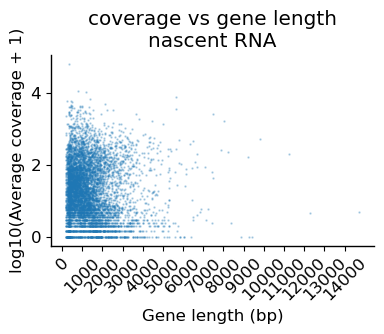

In [443]:
wt_labels = [label for label in samples if 'WT' in label]
result['ave_cov'] = result[wt_labels].mean(axis=1)
df = result[['iso_id', 'ave_cov']].copy()
df['isolen'] = iso_tb['isolen'].values

fig, axes = plt.subplots(1, 1, figsize=(4, 3.5))
ax = axes
ax.scatter(df['isolen'], np.log10(df['ave_cov'] + 1), s=0.5, alpha=0.3)
ax.set_xlabel('Gene length (bp)')
ax.set_ylabel('log10(Average coverage + 1)')
ax.set_title('coverage vs gene length\nnascent RNA')
ax.set_xticks(np.arange(0, 15000, 1000))
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../figures/Supp_nascent_rna_coverage.pdf')

## mature rna aligned readlength after filtering

In [364]:
inpath = "../data/rna/matureRNA/alignment/"
fs = os.listdir(inpath)
bams = sorted([f for f in fs if re.search(r'trimmed.sorted.bam$', f)])
samples = ['WT rep1', 'WT rep2', 'WT rep3', 'MUT rep1', 'MUT rep2', 'MUT rep3']
samples_i  = [3,4,5,0,1,2]
bams = [bams[i] for i in samples_i]
print(bams)
print(samples)

['250915_ys18_rep1_teloprime_trimmed.sorted.bam', '250915_ys18_rep2_teloprime_trimmed.sorted.bam', '250915_ys18_rep3_teloprime_trimmed.sorted.bam', '250915_ym209_rep1_teloprime_trimmed.sorted.bam', '250915_ym209_rep2_teloprime_trimmed.sorted.bam', '250915_ym209_rep3_teloprime_trimmed.sorted.bam']
['WT rep1', 'WT rep2', 'WT rep3', 'MUT rep1', 'MUT rep2', 'MUT rep3']


In [337]:
outf = open('../data/supp/Supp_mature_rna_final_aligned_readlength_qc.tsv', 'w')
outf.write('sample\treadlength_mean\treadlength_median\treadlength_std\t''read_quality_mean\tread_quality_median\tread_quality_std\n')

allreadLens, allreadQuals, readCounts = [], [], []
for i, bam in enumerate(bams):
    print(samples[i])
    readLens, readQuals, readCount = read_level_qc(inpath + bam)
    
    outf.write(
        f"{samples[i]}\t"
        f"{np.mean(readLens):.4f}\t{np.median(readLens):.4f}\t{np.std(readLens):.4f}\t"
        f"{np.mean(readQuals):.4f}\t{np.median(readQuals):.4f}\t{np.std(readQuals):.4f}\n"
    )

    allreadLens.append(readLens)
    allreadQuals.append(readQuals)
    readCounts.append(readCount)

outf.close()

WT rep1
WT rep2
WT rep3
MUT rep1
MUT rep2
MUT rep3


WT rep1
WT rep2
WT rep3
MUT rep1
MUT rep2
MUT rep3


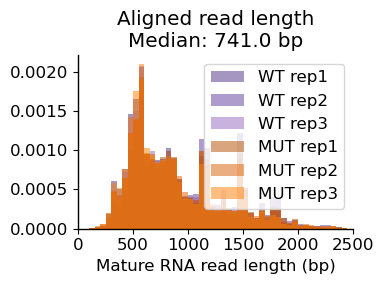

In [341]:
cmap = ['#4B2E83', '#5D3A9B', '#9467bd', '#b24d00', '#d95f02', '#ff7f00']
plt.figure(figsize=(4, 3))
for i, readlen in enumerate(allreadLens):
    print(samples[i])
    readlen_sampled = random.sample(readlen, 10000)
    plt.hist(readlen_sampled, bins=np.arange(0, 2500, 50), density=True, alpha = 0.5, color= cmap[i], label = samples[i])

plt.xlabel('Mature RNA read length (bp)')
median_wt1 = np.median(allreadLens[0])
plt.title(f'Aligned read length\nMedian: {median_wt1} bp')
plt.xlim(0, 2500)
plt.legend()
plt.tight_layout()
plt.savefig('../figures/Supp_maure_rna_final_aligned_readlength.pdf')

In [353]:
inpath = "../data/rna/matureRNA/alignment/"
fs = os.listdir(inpath)
flagstat_files = sorted([f for f in fs if re.search(r'_trimmed.sorted.flagstat$', f)])

samples = ['WT rep1', 'WT rep2', 'WT rep3', 'MUT rep1', 'MUT rep2', 'MUT rep3']
samples_i  = [3,4,5,0,1,2]
flagstat_files = [flagstat_files[i] for i in samples_i]

print(flagstat_files)
print(samples)

['250915_ys18_rep1_teloprime_trimmed.sorted.flagstat', '250915_ys18_rep2_teloprime_trimmed.sorted.flagstat', '250915_ys18_rep3_teloprime_trimmed.sorted.flagstat', '250915_ym209_rep1_teloprime_trimmed.sorted.flagstat', '250915_ym209_rep2_teloprime_trimmed.sorted.flagstat', '250915_ym209_rep3_teloprime_trimmed.sorted.flagstat']
['WT rep1', 'WT rep2', 'WT rep3', 'MUT rep1', 'MUT rep2', 'MUT rep3']


In [354]:
totals, mappeds = [], []
for i, f in enumerate(flagstat_files):
    
    with open(os.path.join(inpath, f)) as fh:
        content = fh.read()

    total = re.search(r"(\d+) \+ \d+ primary", content)
    mapped = re.search(r"(\d+) \+ \d+ primary mapped", content)
    
    n_total = int(total.group(1)) if total else 0
    n_mapped = int(mapped.group(1)) if mapped else 0
    totals.append(n_total)
    mappeds.append(n_mapped)

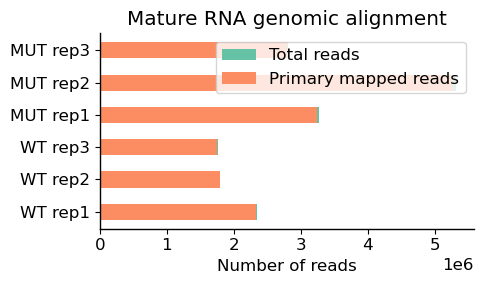

In [357]:
outf = open('../data/supp/Supp_mature_rna_total_read_vs_aligned_reads_qc.tsv', 'w')
outf.write('sample\tprimary_total\tprimary_mapped\n')
for i,s in enumerate(samples):
    outf.write(f'{s}\t{totals[i]}\t{mappeds[i]}\n')
outf.close()

plt.figure(figsize=(5, 3))
plt.barh(samples, totals, height=0.5, color='#66c2a5', label='Total reads')
plt.barh(samples, mappeds, height=0.5, color='#fc8d62', label='Primary mapped reads')
plt.title('Mature RNA genomic alignment')
plt.xlabel("Number of reads")
plt.legend()
plt.tight_layout()
plt.savefig('../figures/Supp_mature_rna_total_number_of_reads.pdf')
plt.show()
plt.close()

## mature rna full-length coverage

In [366]:
iso_tb = pd.read_csv("../data/2_final_iso_tb.tsv", sep="\t", index_col=0)

genes_by_chrom = defaultdict(list)
for _, row in iso_tb.iterrows():
    genes_by_chrom[row["chrom"]].append((int(row["start"]), int(row["end"]), row["iso_id"]))

for chrom in genes_by_chrom:
    genes_by_chrom[chrom].sort()

chrom_starts = {ch: [g[0] for g in gl] for ch, gl in genes_by_chrom.items()}

In [378]:
from bisect import bisect, bisect_left

In [380]:
print(bams)
print(samples)

counts = {label: defaultdict(int) for label in samples}

for bam_path, label in zip(bams, samples):
    with pysam.AlignmentFile(inpath + bam_path, "rb") as samfile:
        for read in samfile:
            if not read.is_mapped or read.is_supplementary or read.is_secondary:
                continue
            chrom = read.reference_name
            if chrom not in chrom_starts:
                continue
            rs, rend = read.reference_start, read.reference_end
            starts = chrom_starts[chrom]
            gl = genes_by_chrom[chrom]

            idx = bisect_left(starts, rs)
            for i in range(idx, len(gl)):
                gstart, gend, gid = gl[i]
                if gstart > rend:
                    break  # all remaining genes start beyond read end
                if gend <= rend:
                    counts[label][gid] += 1



all_genes = iso_tb["iso_id"].unique()
result = pd.DataFrame({"iso_id": all_genes})
for label in samples:
    result[label] = result["iso_id"].map(counts[label]).fillna(0).astype(int)

result.to_csv("../data/6_isoform_full_length_coverage.tsv", sep="\t", index=False)

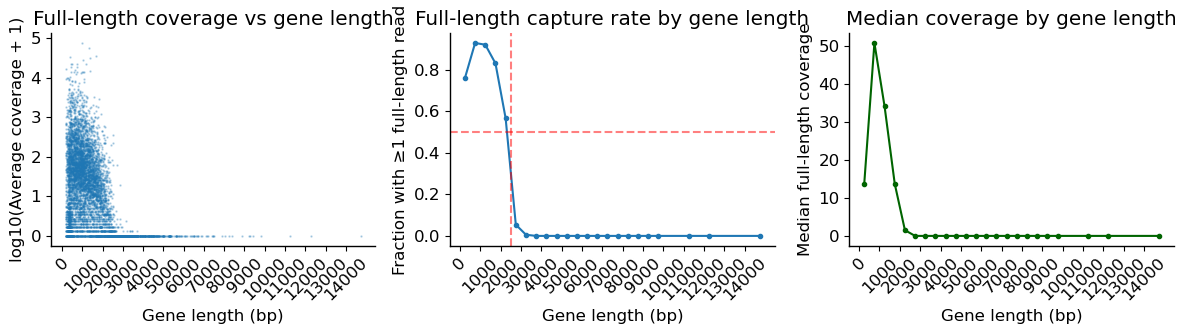

Coverage drops below 50% at gene length ~2500 bp


In [428]:
wt_labels = [label for label in samples if 'WT' in label]
result['ave_cov'] = result[wt_labels].mean(axis=1)
df = result[['iso_id', 'ave_cov']].copy()
df['isolen'] = iso_tb['isolen'].values

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
ax = axes[0]
ax.scatter(df['isolen'], np.log10(df['ave_cov'] + 1), s=0.5, alpha=0.3)
ax.set_xlabel('Gene length (bp)')
ax.set_ylabel('log10(Average coverage + 1)')
ax.set_title('Full-length coverage vs gene length\nmature RNA')


bins = np.arange(0, df['isolen'].max() + 500, 500)
df['len_bin'] = pd.cut(df['isolen'], bins=bins)

binned = df.groupby('len_bin', observed=True).agg(
    n_genes=('ave_cov', 'size'),
    n_covered=('ave_cov', lambda x: (x >= 1).sum())
)
binned['frac_covered'] = binned['n_covered'] / binned['n_genes']
bin_mids = [interval.mid for interval in binned.index]
ax = axes[1]
ax.plot(bin_mids, binned['frac_covered'], marker='o', markersize=3)
ax.set_xlabel('Gene length (bp)')
ax.set_ylabel('Fraction with ≥1 full-length read')
ax.set_title('Full-length capture rate by gene length\nmature RNA')
ax.axhline(0.5, color='red', linestyle='--', alpha=0.5)
ax.axvline(2500, color='red', linestyle='--', alpha=0.5)


ax = axes[2]
binned_med = df.groupby('len_bin', observed=True)['ave_cov'].median()
ax.plot(bin_mids, binned_med, marker='o', markersize=3, color='darkgreen')
ax.set_xlabel('Gene length (bp)')
ax.set_ylabel('Median full-length coverage')
ax.set_title('Median coverage by gene length\nmature RNA')

for ax in axes:
    ax.set_xticks(np.arange(0, 15000, 1000))
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../figures/Supp_mature_rna_gene_full_length_coverage.pdf')
plt.show()

half_cutoff = binned.loc[binned['frac_covered'] < 0.5]
if len(half_cutoff) > 0:
    first_bin = half_cutoff.index[0]
    print(f"Coverage drops below 50% at gene length ~{int(first_bin.left)} bp")
else:
    print("Coverage stays above 50% across all gene lengths")